<a href="https://colab.research.google.com/github/eddiejaques/ml-code-samples/blob/main/Security%20Breaches%20Dataset/data_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Security Data — Logistic Regression (Multiple Logistic Regression)

## Dataset
Data sourced from `security_data_10000.csv` (synthetic data generated from original class dataset).

| Column | Description |
|--------|-------------|
| Sector | Industry sector of the company |
| CEO_Gender | Gender of the CEO (Male/Female) |
| Size | Company size (Large, Medium, Small) |
| Security_Invest | Security investment amount |
| Security_Breach_Att | Number of security breach attempts |
| Succ_Sec_Breaches | Number of successful security breaches |
| Sec_Rating | Overall security rating (High/Medium/Low) |
| CEO_Sec_Exp | CEO's level of security experience (High/Medium/Low) |
| LOT_in_Business | Length of time in business (years) |
| Stock_Market | Whether the company is listed on the stock market (Yes/No) |

---

## Objective
Predict whether a company is **listed on the stock market (Yes/No)** using all available features.

**Target variable:** `Stock_Market` (Yes = True / No = False)

---

## Data Analysis Plan

1.  **Load Data** — Read CSV into DataFrame
2.  **Train-Test Split** — Split before any feature engineering
3.  **Create Binary Label** — Encode `Stock_Market` as True/False
4.  **Drop Target from Features** — Remove `Stock_Market` from input features
5.  **Encode Categorical Features** — One-hot encode remaining categorical columns
6.  **Fit Logistic Regression** — Use `class_weight='balanced'` to handle class imbalance
7.  **Evaluate** — Confusion matrix and classification report on train and test

## Step 1 — Load Dataset

In [ ]:
#LOAD THE DATASET


import pandas as pd

file_url = "https://raw.githubusercontent.com/eddiejaques/ml-code-samples/refs/heads/main/Security%20Breaches%20Dataset/security_data_10000.csv"

security_df = pd.read_csv(file_url)

security_df.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Banking,Female,Small,17,11,2,Medium,High,13,No
1,Banking,Male,Small,18,12,4,High,Low,9,No
2,Banking,Male,Small,17,12,4,High,Medium,22,No
3,Banking,Male,Small,24,13,1,High,Medium,3,Yes
4,Banking,Male,Small,32,14,3,High,Medium,4,Yes


## Step 2 — Train-Test Split
Split performed **before** any feature engineering to prevent data leakage.

In [2]:
from sklearn.model_selection import train_test_split
security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)

### Step 3 — Exploratory Data Analysis (EDA)

In [3]:
security_df_train.describe()

,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
count,48.000000,48.000000,48.000000,48.000000
mean,66.604167,54.979167,24.229167,9.125000
std,75.107225,59.456220,24.295381,6.625627
min,12.000000,7.000000,0.000000,1.000000
25%,21.000000,16.250000,4.000000,3.000000
50%,32.000000,40.000000,19.000000,8.000000
75%,93.000000,77.000000,34.000000,14.000000
max,435.000000,321.000000,100.000000,22.000000


In [4]:
security_df_train.isna().sum()

Sector                 0
CEO_Gender             0
Size                   0
Security_Invest        0
Security_Breach_Att    0
Succ_Sec_Breaches      0
Sec_Rating             0
CEO_Sec_Exp            0
LOT_in_Business        0
Stock_Market           0
dtype: int64

## Step 4 — Create Binary Label
Encode `Stock_Market` as a boolean: `True` = Yes, `False` = No.
This will be the target variable for the logistic regression model.

In [5]:
security_df_train_label = (security_df_train["Stock_Market"] == 'Yes')

security_df_test_label = (security_df_test["Stock_Market"] =='Yes')

In [6]:
security_df_train.shape

(48, 10)

## Step 5 — Drop Target Column from Features
`Stock_Market` must be removed from the input features — it is the target variable, not a predictor.

In [7]:
security_df_train = security_df_train.drop("Stock_Market", axis=1)
security_df_train.shape

(48, 9)

In [8]:
security_df_test = security_df_test.drop("Stock_Market", axis=1)
security_df_test.shape

(12, 9)

In [9]:
numerical_cols = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]
categorical_cols = ["Sector", "Size", "Sec_Rating", "CEO_Sec_Exp", "CEO_Gender"]

In [10]:
security_df_train.describe()

,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
count,48.000000,48.000000,48.000000,48.000000
mean,66.604167,54.979167,24.229167,9.125000
std,75.107225,59.456220,24.295381,6.625627
min,12.000000,7.000000,0.000000,1.000000
25%,21.000000,16.250000,4.000000,3.000000
50%,32.000000,40.000000,19.000000,8.000000
75%,93.000000,77.000000,34.000000,14.000000
max,435.000000,321.000000,100.000000,22.000000


In [11]:
security_df_train.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business
31,Hospitality,Male,Medium,91,184,85,Medium,High,21
3,Banking,Male,Small,24,13,1,High,Medium,3
52,Hospitality,Male,Large,87,77,33,Low,Medium,8
17,Health Care,Male,Small,27,20,8,High,High,4
8,Hospitality,Male,Small,99,77,34,Low,Medium,3


## Step 6 — Impute

In [12]:
print(security_df_train.shape)
print(security_df_test.shape)


from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

security_df_train_num = pd.DataFrame(imputer.fit_transform(security_df_train[numerical_cols]), columns=numerical_cols)

security_df_test_num = pd.DataFrame(imputer.transform(security_df_test[numerical_cols]), columns=numerical_cols)

security_df_train_final = pd.concat([security_df_train_num.reset_index(drop=True), security_df_train[categorical_cols].reset_index(drop=True)], axis=1)

security_df_test_final = pd.concat([security_df_test_num.reset_index(drop=True), security_df_test[categorical_cols].reset_index(drop=True)], axis=1)

security_df_train_final.head()


(48, 9)
(12, 9)


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,Sector,Size,Sec_Rating,CEO_Sec_Exp,CEO_Gender
0,91.0,184.0,85.0,21.0,Hospitality,Medium,Medium,High,Male
1,24.0,13.0,1.0,3.0,Banking,Small,High,Medium,Male
2,87.0,77.0,33.0,8.0,Hospitality,Large,Low,Medium,Male
3,27.0,20.0,8.0,4.0,Health Care,Small,High,High,Male
4,99.0,77.0,34.0,3.0,Hospitality,Small,Low,Medium,Male


## Step 7 — Remove Outliers

In [13]:
print("Shape of security_df_train_final:", security_df_train_final.shape)
print("Shape of security_df_test_final:", security_df_test_final.shape)

from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)

outliers = isolation_forest.fit_predict(security_df_train_final[numerical_cols])

print ("Number of outliers detected:", (outliers == -1).sum())

security_df_train_final = security_df_train_final[outliers == 1]

security_df_train_label = security_df_train_label[outliers == 1]

print("Shape of security_df_train_final:", security_df_train_final.shape)

print("Shape of security_df_test_final:", security_df_test_final.shape)

Shape of security_df_train_final: (48, 9)
Shape of security_df_test_final: (12, 9)
Number of outliers detected: 11
Shape of security_df_train_final: (37, 9)
Shape of security_df_test_final: (12, 9)


## Step 8 — Encode Categorical Features
One-hot encode all remaining categorical columns. `dtype=int` ensures 0/1 output instead of True/False.
Original categorical columns are dropped after encoding to avoid duplication.

In [14]:

security_df_train_cat = pd.get_dummies( security_df_train_final[categorical_cols], dtype=int)
security_df_test_cat = pd.get_dummies(security_df_test_final[categorical_cols], dtype=int)

# Align columns after one-hot encoding
aligned_cols = list(set(security_df_train_cat.columns) | set(security_df_test_cat.columns))
security_df_train_cat = security_df_train_cat.reindex(columns=aligned_cols, fill_value=0)
security_df_test_cat = security_df_test_cat.reindex(columns=aligned_cols, fill_value=0)

security_df_train_final = pd.concat([security_df_train_final[numerical_cols].reset_index(drop=True), security_df_train_cat.reset_index(drop=True)], axis=1)
security_df_test_final = pd.concat([security_df_test_final[numerical_cols].reset_index(drop=True), security_df_test_cat.reset_index(drop=True)], axis=1)

print("Shape of security_df_train_final:", security_df_train_final.shape)

print("Shape of security_df_test_final:", security_df_test_final.shape)

security_df_train_final.head()

Shape of security_df_train_final: (37, 18)
Shape of security_df_test_final: (12, 18)


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,CEO_Sec_Exp_High,Sector_Banking,Sec_Rating_Low,Sec_Rating_High,CEO_Gender_Female,Size_Large,Sector_Hospitality,Sec_Rating_Medium,CEO_Gender_Male,CEO_Sec_Exp_Low,Sector_Health Care,Size_Medium,CEO_Sec_Exp_Medium,Size_Small
0,24.0,13.0,1.0,3.0,0,1,0,1,0,0,0,0,1,0,0,0,1,1
1,87.0,77.0,33.0,8.0,0,0,1,0,0,1,1,0,1,0,0,0,1,0
2,27.0,20.0,8.0,4.0,1,0,0,1,0,0,0,0,1,0,1,0,0,1
3,99.0,77.0,34.0,3.0,0,0,1,0,0,0,1,0,1,0,0,0,1,1
4,43.0,11.0,0.0,12.0,1,1,0,1,0,0,0,0,1,0,0,0,0,1


## Step 9 — Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]

security_df_train_scaled = pd.DataFrame(scaler.fit_transform(security_df_train_final[numerical_cols]), columns=numerical_cols)

security_df_test_scaled = pd.DataFrame(scaler.transform(security_df_test_final[numerical_cols]), columns=numerical_cols)

security_df_train_final = pd.concat([security_df_train_final.drop(columns=numerical_cols), security_df_train_scaled], axis=1)

security_df_test_final =  pd.concat([security_df_test_final.drop(columns=numerical_cols), security_df_test_scaled], axis=1)

print("Shape of security_df_train_final:", security_df_train_final.shape)

print("Shape of security_df_test_final:", security_df_test_final.shape)

security_df_train_final.head()


Shape of security_df_train_final: (37, 18)
Shape of security_df_test_final: (12, 18)


,CEO_Sec_Exp_High,Sector_Banking,Sec_Rating_Low,Sec_Rating_High,CEO_Gender_Female,Size_Large,Sector_Hospitality,Sec_Rating_Medium,CEO_Gender_Male,CEO_Sec_Exp_Low,Sector_Health Care,Size_Medium,CEO_Sec_Exp_Medium,Size_Small,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
0,0,1,0,1,0,0,0,0,1,0,0,0,1,1,-0.551962,-0.920327,-1.038603,-0.821642
1,0,0,1,0,0,1,1,0,1,0,0,0,1,0,1.239992,1.845326,1.242855,0.018158
2,1,0,0,1,0,0,0,0,1,0,1,0,0,1,-0.466631,-0.617834,-0.539534,-0.653682
3,0,0,1,0,0,0,1,0,1,0,0,0,1,1,1.581317,1.845326,1.314151,-0.821642
4,1,1,0,1,0,0,0,0,1,0,0,0,0,1,-0.011531,-1.006754,-1.109899,0.689997


## Step 10 — Fit Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = log_reg = LogisticRegression(class_weight="balanced", solver='liblinear', random_state=42)

logistic_model.fit(security_df_train_final, security_df_train_label)

security_df_train_label_pred = logistic_model.predict(security_df_train_final)

security_df_test_label_pred = logistic_model.predict(security_df_test_final)
print(f"Shape of security_df_test_final: {security_df_test_final.shape}")
print(f"Shape of security_df_test_label_pred: {security_df_test_label_pred.shape}")

Shape of security_df_test_final: (12, 18)
Shape of security_df_test_label_pred: (12,)


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix - Train:")

print(confusion_matrix(security_df_train_label, security_df_train_label_pred))

print("Classification Report - Train:")

print(classification_report(security_df_train_label, security_df_train_label_pred))

print("Confusion Matrix - Test:")

print(confusion_matrix(security_df_test_label, security_df_test_label_pred))

print("Classification Report - Test:")

print(classification_report(security_df_test_label, security_df_test_label_pred))

Confusion Matrix - Train:
[[ 7  3]
 [10 17]]
Classification Report - Train:
              precision    recall  f1-score   support

       False       0.41      0.70      0.52        10
        True       0.85      0.63      0.72        27

    accuracy                           0.65        37
   macro avg       0.63      0.66      0.62        37
weighted avg       0.73      0.65      0.67        37

Confusion Matrix - Test:
[[4 3]
 [1 4]]
Classification Report - Test:
              precision    recall  f1-score   support

       False       0.80      0.57      0.67         7
        True       0.57      0.80      0.67         5

    accuracy                           0.67        12
   macro avg       0.69      0.69      0.67        12
weighted avg       0.70      0.67      0.67        12



## Step 11 — Evaluate
- **Confusion matrix** — shows True/False Positives and Negatives
- **Precision** — of all predicted Male/Female, how many were correct
- **Recall** — of all actual Male/Female, how many were caught
- **F1-score** — harmonic mean of precision and recall

---

## Step 12 — Evaluate Ordinal Encoding Experiment
Re-run logistic regression replacing one-hot encoding for `Size`, `CEO_Sec_Exp`, and `Sec_Rating` with **OrdinalEncoder** (preserving natural order), while keeping one-hot encoding for `Sector` and `CEO_Gender`.

In [18]:
from sklearn.preprocessing import OrdinalEncoder

# Reload clean post-outlier-removal data (re-derive from original split)
security_df2 = pd.read_csv(file_url)
train2, test2 = train_test_split(security_df2, test_size=0.2, random_state=42)

label_train2 = (train2["Stock_Market"] == "Yes")
label_test2  = (test2["Stock_Market"] == "Yes")

train2 = train2.drop("Stock_Market", axis=1)
test2  = test2.drop("Stock_Market", axis=1)

numerical_cols2   = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]
ordinal_cols      = ["Size", "CEO_Sec_Exp", "Sec_Rating"]
onehot_cols2      = ["Sector", "CEO_Gender"]

# Impute numerics
from sklearn.impute import SimpleImputer
imputer2 = SimpleImputer(strategy="median")
train2_num = pd.DataFrame(imputer2.fit_transform(train2[numerical_cols2]), columns=numerical_cols2)
test2_num  = pd.DataFrame(imputer2.transform(test2[numerical_cols2]),      columns=numerical_cols2)

train2_combined = pd.concat([train2_num, train2[ordinal_cols + onehot_cols2].reset_index(drop=True)], axis=1)
test2_combined  = pd.concat([test2_num,  test2[ordinal_cols + onehot_cols2].reset_index(drop=True)], axis=1)

# Remove outliers (same IsolationForest config)
iso2 = IsolationForest(random_state=42)
mask2 = iso2.fit_predict(train2_combined[numerical_cols2])
train2_combined = train2_combined[mask2 == 1].reset_index(drop=True)
label_train2    = label_train2[mask2 == 1].reset_index(drop=True)

print(f"Train shape after outlier removal: {train2_combined.shape}")

# Ordinal encode Size / CEO_Sec_Exp / Sec_Rating
ordinal_categories = [
    ["Small", "Medium", "Large"],   # Size
    ["Low",   "Medium", "High"],    # CEO_Sec_Exp
    ["Low",   "Medium", "High"],    # Sec_Rating
]
enc = OrdinalEncoder(categories=ordinal_categories)
train2_ord = pd.DataFrame(enc.fit_transform(train2_combined[ordinal_cols]), columns=ordinal_cols)
test2_ord  = pd.DataFrame(enc.transform(test2_combined[ordinal_cols]),      columns=ordinal_cols)

# One-hot encode Sector / CEO_Gender
train2_ohe = pd.get_dummies(train2_combined[onehot_cols2], dtype=int)
test2_ohe  = pd.get_dummies(test2_combined[onehot_cols2],  dtype=int)
ohe_cols   = list(set(train2_ohe.columns) | set(test2_ohe.columns))
train2_ohe = train2_ohe.reindex(columns=ohe_cols, fill_value=0)
test2_ohe  = test2_ohe.reindex(columns=ohe_cols,  fill_value=0)

# Scale numerics
scaler2 = StandardScaler()
train2_scaled = pd.DataFrame(scaler2.fit_transform(train2_combined[numerical_cols2]), columns=numerical_cols2)
test2_scaled  = pd.DataFrame(scaler2.transform(test2_combined[numerical_cols2]),       columns=numerical_cols2)

# Assemble final feature matrices
X_train2 = pd.concat([train2_scaled, train2_ord.reset_index(drop=True), train2_ohe.reset_index(drop=True)], axis=1)
X_test2  = pd.concat([test2_scaled,  test2_ord,                          test2_ohe],                         axis=1)

print(f"X_train2 shape: {X_train2.shape}")
print(f"X_test2  shape: {X_test2.shape}")
X_train2.head()

Train shape after outlier removal: (37, 9)
X_train2 shape: (37, 12)
X_test2  shape: (12, 12)


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,Size,CEO_Sec_Exp,Sec_Rating,Sector_Banking,Sector_Hospitality,CEO_Gender_Male,Sector_Health Care,CEO_Gender_Female
0,-0.551962,-0.920327,-1.038603,-0.821642,0.0,1.0,2.0,1,0,1,0,0
1,1.239992,1.845326,1.242855,0.018158,2.0,1.0,0.0,0,1,1,0,0
2,-0.466631,-0.617834,-0.539534,-0.653682,0.0,2.0,2.0,0,0,1,1,0
3,1.581317,1.845326,1.314151,-0.821642,0.0,1.0,0.0,0,1,1,0,0
4,-0.011531,-1.006754,-1.109899,0.689997,0.0,2.0,2.0,1,0,1,0,0


In [19]:
# Fit logistic regression with ordinal-encoded features
logistic_model2 = LogisticRegression(class_weight="balanced", solver="liblinear", random_state=42)
logistic_model2.fit(X_train2, label_train2)

pred_train2 = logistic_model2.predict(X_train2)
pred_test2  = logistic_model2.predict(X_test2)

print("=== Ordinal Encoding — Train ===")
print(confusion_matrix(label_train2, pred_train2))
print(classification_report(label_train2, pred_train2))

print("=== Ordinal Encoding — Test ===")
print(confusion_matrix(label_test2, pred_test2))
print(classification_report(label_test2, pred_test2))

=== Ordinal Encoding — Train ===
[[ 9  1]
 [ 9 18]]
              precision    recall  f1-score   support

       False       0.50      0.90      0.64        10
        True       0.95      0.67      0.78        27

    accuracy                           0.73        37
   macro avg       0.72      0.78      0.71        37
weighted avg       0.83      0.73      0.74        37

=== Ordinal Encoding — Test ===
[[5 2]
 [1 4]]
              precision    recall  f1-score   support

       False       0.83      0.71      0.77         7
        True       0.67      0.80      0.73         5

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12



In [20]:
from sklearn.metrics import accuracy_score, f1_score

# One-hot model scores (from earlier cells)
ohe_test_acc = accuracy_score(security_df_test_label, security_df_test_label_pred)
ohe_test_f1  = f1_score(security_df_test_label, security_df_test_label_pred, average="macro")

# Ordinal model scores
ord_test_acc = accuracy_score(label_test2, pred_test2)
ord_test_f1  = f1_score(label_test2, pred_test2, average="macro")

comparison = pd.DataFrame({
    "Encoding":       ["One-Hot (baseline)", "Ordinal (Size/CEO_Sec_Exp/Sec_Rating)"],
    "Test Accuracy":  [f"{ohe_test_acc:.2%}", f"{ord_test_acc:.2%}"],
    "Test Macro F1":  [f"{ohe_test_f1:.2%}", f"{ord_test_f1:.2%}"],
})
comparison

,Encoding,Test Accuracy,Test Macro F1
0,One-Hot (baseline),66.67%,66.67%
1,Ordinal (Size/CEO_Sec_Exp/Sec_Rating),75.00%,74.83%


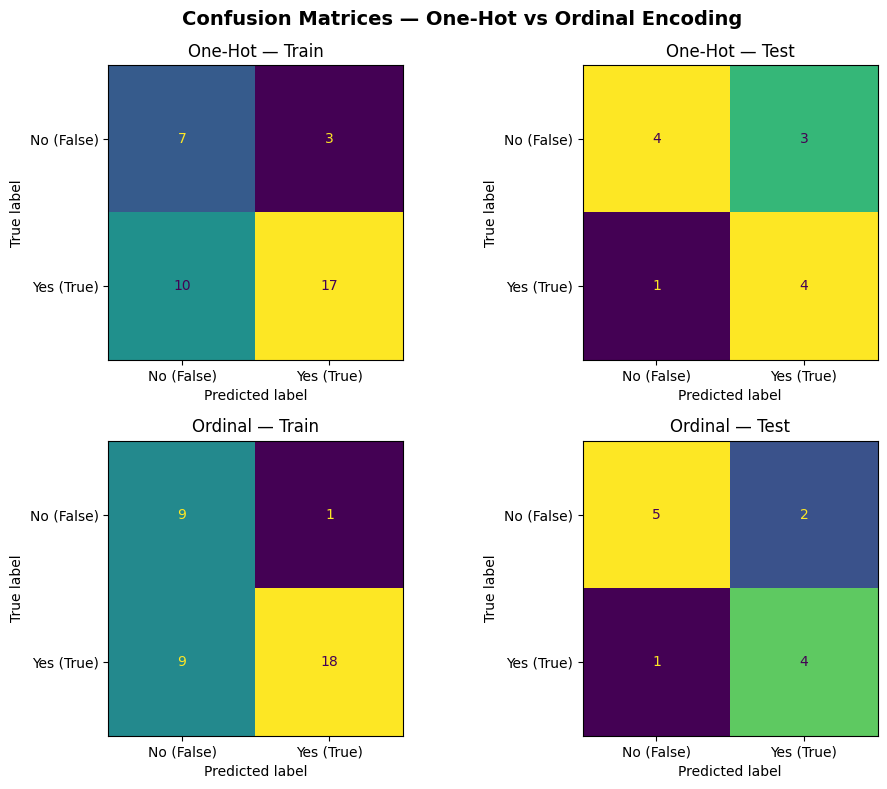

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Confusion Matrices — One-Hot vs Ordinal Encoding", fontsize=14, fontweight="bold")

datasets = [
    (security_df_train_label, security_df_train_label_pred, "One-Hot — Train"),
    (security_df_test_label,  security_df_test_label_pred,  "One-Hot — Test"),
    (label_train2,            pred_train2,                  "Ordinal — Train"),
    (label_test2,             pred_test2,                   "Ordinal — Test"),
]

for ax, (y_true, y_pred, title) in zip(axes.flat, datasets):
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["No (False)", "Yes (True)"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()